# WP3 — Evaluation of MAE → CLIP Projection Models

This notebook tests all trained models **without re-running training**.

## Models

| Notebook | Model                   | Architecture | Feature | Aug   |
|----------|-------------------------|--------------|---------|-------|
| [wp3_2]  | MLP   + z_full          | ProjectionMLP   | z_full | —    |
| [wp3_3]  | MLPv2 + z_full          | ProjectionMLPv2 | z_full | —    |
| [wp3_4]  | MLP   + z_cls           | ProjectionMLP   | z_cls  | —    |
| [wp3_4]  | MLPv2 + z_cls           | ProjectionMLPv2 | z_cls  | —    |
| [wp3_5]  | MLP   + z_full + aug K=5 | ProjectionMLP   | z_full | K=5 |
| [wp3_5]  | MLPv2 + z_full + aug K=5 | ProjectionMLPv2 | z_full | K=5 |
| [wp3_6]  | MLP   + z_cls  + aug K=5 | ProjectionMLP   | z_cls  | K=5 |
| [wp3_6]  | MLPv2 + z_cls  + aug K=5 | ProjectionMLPv2 | z_cls  | K=5 |

- **z_full** : mean of all patch tokens
- **z_cls** : CLS token only
- **aug K=5** : 75% masking applied at inference

## Required files
```
projection_mlp_best.pt           projection_mlpv2_best.pt
projection_cls_mlp_best.pt       projection_cls_mlpv2_best.pt
projection_aug_mlp_best.pt       projection_aug_mlpv2_best.pt
projection_cls_aug_mlp_best.pt   projection_cls_aug_mlpv2_best.pt

z_full_norm_stats.pt             z_cls_norm_stats.pt
z_aug_K5_norm_stats.pt           z_cls_aug_K5_norm_stats.pt
```

## 0. Dataset

In [22]:
import os
from datasets import load_dataset
from huggingface_hub import snapshot_download

DATASET_DIR = './imagenet100-hf'

if not os.path.exists(f'{DATASET_DIR}/data'):
    print('Downloading ImageNet-100...')
    snapshot_download(repo_id='ilee0022/ImageNet100', repo_type='dataset', local_dir=DATASET_DIR)
    print('Done.')
else:
    print(f'Dataset found')


Dataset found


## 1. Load MAE and CLIP

In [23]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViTImageProcessor, ViTMAEModel, CLIPProcessor, CLIPModel
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

MAE_PATH  = './vit-mae-large'        if os.path.exists('./vit-mae-large')        else 'facebook/vit-mae-large'
CLIP_PATH = './clip-vit-large-patch14' if os.path.exists('./clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'

mae_processor = ViTImageProcessor.from_pretrained(MAE_PATH)
mae_encoder   = ViTMAEModel.from_pretrained(MAE_PATH).to(DEVICE).eval()

clip_model     = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)

print('MAE and CLIP loaded.')


Device : cpu
MAE and CLIP loaded.


## 2. MLP Architectures

In [29]:
class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class ProjectionMLPv2(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


## 3. Load All Models

In [25]:
# (name, checkpoint, stats, architecture, feature_type, masked)
MODEL_CONFIGS = [
    ('wp3_2 baseline', 'projection_mlp_best.pt',           'z_full_norm_stats.pt',       ProjectionMLP,   'z_full', False),
    ('wp3_3 v2',       'projection_mlpv2_best.pt',          'z_full_norm_stats.pt',       ProjectionMLPv2, 'z_full', False),
    ('wp3_4 baseline', 'projection_cls_mlp_best.pt',        'z_cls_norm_stats.pt',        ProjectionMLP,   'z_cls',  False),
    ('wp3_4 v2',       'projection_cls_mlpv2_best.pt',      'z_cls_norm_stats.pt',        ProjectionMLPv2, 'z_cls',  False),
    ('wp3_5 baseline', 'projection_aug_mlp_best.pt',        'z_aug_K5_norm_stats.pt',     ProjectionMLP,   'z_full', True),
    ('wp3_5 v2',       'projection_aug_mlpv2_best.pt',      'z_aug_K5_norm_stats.pt',     ProjectionMLPv2, 'z_full', True),
    ('wp3_6 baseline', 'projection_cls_aug_mlp_best.pt',    'z_cls_aug_K5_norm_stats.pt', ProjectionMLP,   'z_cls',  True),
    ('wp3_6 v2',       'projection_cls_aug_mlpv2_best.pt',  'z_cls_aug_K5_norm_stats.pt', ProjectionMLPv2, 'z_cls',  True),
]

NAME_MAP = {
    'wp3_2 baseline': ('[wp3_2]', 'MLP   + z_full'),
    'wp3_3 v2':       ('[wp3_3]', 'MLPv2 + z_full'),
    'wp3_4 baseline': ('[wp3_4]', 'MLP   + z_cls'),
    'wp3_4 v2':       ('[wp3_4]', 'MLPv2 + z_cls'),
    'wp3_5 baseline': ('[wp3_5]', 'MLP   + z_full + aug K=5'),
    'wp3_5 v2':       ('[wp3_5]', 'MLPv2 + z_full + aug K=5'),
    'wp3_6 baseline': ('[wp3_6]', 'MLP   + z_cls  + aug K=5'),
    'wp3_6 v2':       ('[wp3_6]', 'MLPv2 + z_cls  + aug K=5'),
}

models = {}
sep  = '=' * 44
dash = '-' * 44
print(sep)
print(f'  {"Notebook":<10}  {"Model"}')
print(dash)
for name, ckpt, stats_file, arch, feat, masked in MODEL_CONFIGS:
    if not os.path.exists(ckpt):
        print(f'  [SKIP]  {name} — {ckpt} not found')
        continue
    s = torch.load(stats_file, weights_only=False)
    m = arch().to(DEVICE)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=False))
    m.eval()
    models[name] = {'model': m, 'mean': s['mean'], 'std': s['std'], 'feat': feat, 'masked': masked}
    tag, label = NAME_MAP[name]
    print(f'  {tag:<10}  {label}')
print(sep)
print(f'{len(models)} model(s) loaded.')


  Notebook    Model
--------------------------------------------
  [wp3_2]     MLP   + z_full
  [wp3_3]     MLPv2 + z_full
  [wp3_4]     MLP   + z_cls
  [wp3_4]     MLPv2 + z_cls
  [wp3_5]     MLP   + z_full + aug K=5
  [wp3_5]     MLPv2 + z_full + aug K=5
  [wp3_6]     MLP   + z_cls  + aug K=5
  [wp3_6]     MLPv2 + z_cls  + aug K=5
8 model(s) loaded.


## 4. Encode CLIP Class Embeddings

In [26]:
with open('imagenet100-hf/label2text.json') as f:
    label2text = json.load(f)

class_names = list(label2text.values())
concepts = [f'a photo of a {n}' for n in class_names]

text_inputs = clip_processor(text=concepts, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
    text_out = clip_model.text_model(**text_inputs)
    text_features = clip_model.text_projection(text_out.pooler_output)
text_features = F.normalize(text_features.float(), dim=-1)

print(f'{len(class_names)} classes encoded')


100 classes encoded


## 5. Inference Functions

In [27]:
def get_mae_embedding(image_pil, feat_type='z_full', masked=False, seed=42):
    inputs = mae_processor(images=image_pil, return_tensors='pt')
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    if masked:
        g = torch.Generator(device=DEVICE)
        g.manual_seed(seed)
        noise = torch.rand(1, 196, generator=g, device=DEVICE)
    else:
        noise = torch.zeros(1, 196, device=DEVICE)
    with torch.no_grad():
        out = mae_encoder(**inputs, noise=noise)
    if feat_type == 'z_cls':
        return out.last_hidden_state[:, 0].cpu()
    else:
        return out.last_hidden_state[:, 1:].mean(dim=1).cpu()


def predict(image_pil, model_name, top_k=3):
    cfg = models[model_name]
    z = get_mae_embedding(image_pil, feat_type=cfg['feat'], masked=cfg['masked'])
    z_norm = (z - cfg['mean']) / cfg['std']
    with torch.no_grad():
        z_proj = cfg['model'](z_norm.to(DEVICE))
    sims = (z_proj @ text_features.T)[0]
    top = sims.topk(top_k)
    return [(class_names[i], sims[i].item()) for i in top.indices.tolist()]


## 6. Test on a Custom Image

**Set `IMAGE_PATH`** to the path of your image. If left as `None`, the first validation image is used.

Image val[0] — true label : white stork


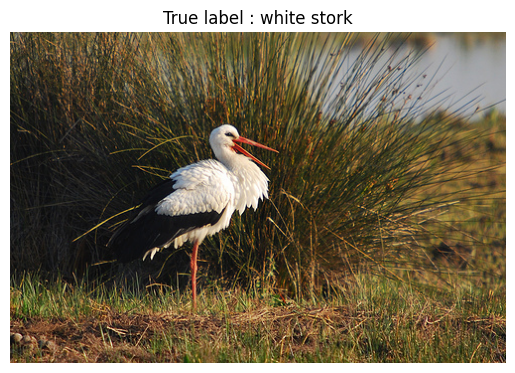


True label : white stork
  Notebook    Model                       Predictions (Top-5)
-------------------------------------------------------------------------------------
  [wp3_2]     MLP   + z_full              white stork (0.250) | spoonbill (0.236) | pelican (0.230) | goose (0.222) | crane (0.219)  v
  [wp3_3]     MLPv2 + z_full              drake (0.233) | spoonbill (0.227) | crane (0.216) | flamingo (0.209) | American coot (0.209)  x
  [wp3_4]     MLP   + z_cls               spoonbill (0.265) | white stork (0.264) | pelican (0.259) | flamingo (0.246) | crane (0.243)  x
  [wp3_4]     MLPv2 + z_cls               drake (0.243) | spoonbill (0.226) | crane (0.215) | American coot (0.203) | pelican (0.194)  x
  [wp3_5]     MLP   + z_full + aug K=5    white stork (0.307) | spoonbill (0.253) | oystercatcher (0.223) | crane (0.222) | pelican (0.212)  v
  [wp3_5]     MLPv2 + z_full + aug K=5    white stork (0.336) | bustard (0.246) | crane (0.238) | drake (0.224) | spoonbill (0.223)  v


In [28]:
# =========================================
IMAGE_PATH = None   # e.g. './cat.jpg'
TRUE_LABEL = None   # e.g. 'flamingo'  (optional)
TOP_K = 5
# =========================================
if IMAGE_PATH is None:
    from datasets import load_dataset
    val_ds = load_dataset(
        'parquet', data_files={
            'validation': 'imagenet100-hf/data/validation-*.parquet'})['validation']
    img_pil = val_ds[0]['image'].convert('RGB')
    TRUE_LABEL = label2text[str(val_ds[0]['label'])]
    print(f'Image val[0] — true label : {TRUE_LABEL}')
else:
    img_pil = Image.open(IMAGE_PATH).convert('RGB')

plt.imshow(img_pil)
plt.axis('off')
plt.title(f'True label : {TRUE_LABEL}' if TRUE_LABEL else 'Image')
plt.show()

NAME_MAP = {
    'wp3_2 baseline': ('[wp3_2]', 'MLP   + z_full'),
    'wp3_3 v2':       ('[wp3_3]', 'MLPv2 + z_full'),
    'wp3_4 baseline': ('[wp3_4]', 'MLP   + z_cls'),
    'wp3_4 v2':       ('[wp3_4]', 'MLPv2 + z_cls'),
    'wp3_5 baseline': ('[wp3_5]', 'MLP   + z_full + aug K=5'),
    'wp3_5 v2':       ('[wp3_5]', 'MLPv2 + z_full + aug K=5'),
    'wp3_6 baseline': ('[wp3_6]', 'MLP   + z_cls  + aug K=5'),
    'wp3_6 v2':       ('[wp3_6]', 'MLPv2 + z_cls  + aug K=5'),
}

sep  = '=' * 85
dash = '-' * 85
print(f'\n{sep}')
if TRUE_LABEL:
    print(f'True label : {TRUE_LABEL}')
print(sep)
print(f'  {"Notebook":<10}  {"Model":<26}  Predictions (Top-{TOP_K})')
print(dash)
for name in models:
    preds = predict(img_pil, name, top_k=TOP_K)
    top1 = preds[0][0]
    mark = '  v' if TRUE_LABEL and top1 == TRUE_LABEL else '  x' if TRUE_LABEL else ''
    top_str = ' | '.join(f'{c} ({s:.3f})' for c, s in preds)
    tag, label = NAME_MAP.get(name, ('[?]', name))
    print(f'  {tag:<10}  {label:<26}  {top_str}{mark}')
print(sep)


## 7. Final Evaluation on the Test Set (5,000 images)

In [8]:
from datasets import load_dataset
from tqdm.auto import tqdm

test_ds = load_dataset(
    'parquet', data_files={
        'test': 'imagenet100-hf/data/test-*.parquet'})['test']
print(f'Test set : {len(test_ds)} images')

correct = {name: 0 for name in models}

for i in tqdm(range(len(test_ds)), desc='Evaluating test set'):
    img_pil = test_ds[i]['image'].convert('RGB')
    true_label = label2text[str(test_ds[i]['label'])]
    inputs = mae_processor(images=img_pil, return_tensors='pt')
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        out_unmasked = mae_encoder(**inputs, noise=torch.zeros(1, 196, device=DEVICE))
        g = torch.Generator(device=DEVICE)
        g.manual_seed(42)
        out_masked = mae_encoder(**inputs, noise=torch.rand(1, 196, generator=g, device=DEVICE))
    z_full_unmasked = out_unmasked.last_hidden_state[:, 1:].mean(1).cpu()
    z_cls_unmasked = out_unmasked.last_hidden_state[:, 0].cpu()
    z_full_masked = out_masked.last_hidden_state[:, 1:].mean(1).cpu()
    z_cls_masked = out_masked.last_hidden_state[:, 0].cpu()
    embeddings = {
        ('z_full', False): z_full_unmasked,
        ('z_cls', False): z_cls_unmasked,
        ('z_full', True): z_full_masked,
        ('z_cls', True): z_cls_masked,
    }
    for name, cfg in models.items():
        z = embeddings[(cfg['feat'], cfg['masked'])]
        z_norm = (z - cfg['mean']) / cfg['std']
        with torch.no_grad():
            z_proj = cfg['model'](z_norm.to(DEVICE))
        pred = class_names[(z_proj @ text_features.T).argmax().item()]
        if pred == true_label:
            correct[name] += 1

NAME_MAP = {
    'wp3_2 baseline': ('[wp3_2]', 'MLP   + z_full'),
    'wp3_3 v2':       ('[wp3_3]', 'MLPv2 + z_full'),
    'wp3_4 baseline': ('[wp3_4]', 'MLP   + z_cls'),
    'wp3_4 v2':       ('[wp3_4]', 'MLPv2 + z_cls'),
    'wp3_5 baseline': ('[wp3_5]', 'MLP   + z_full + aug K=5'),
    'wp3_5 v2':       ('[wp3_5]', 'MLPv2 + z_full + aug K=5'),
    'wp3_6 baseline': ('[wp3_6]', 'MLP   + z_cls  + aug K=5'),
    'wp3_6 v2':       ('[wp3_6]', 'MLPv2 + z_cls  + aug K=5'),
}

N = len(test_ds)
sep  = '=' * 60
dash = '-' * 60
print(f'\nTop-1 accuracy — test set ({N} images) :')
print(sep)
print(f'  {"Notebook":<10}  {"Model":<26}  {"Correct":>9}   Acc')
print(dash)
for name, n_ok in sorted(correct.items(), key=lambda x: x[1], reverse=True):
    tag, label = NAME_MAP.get(name, ('[?]', name))
    print(f'  {tag:<10}  {label:<26}  {n_ok:4d}/{N}  ({100*n_ok/N:.1f}%)')
print(sep)


Generating test split: 0 examples [00:00, ? examples/s]

Test set : 5000 images


Evaluating test set:   0%|          | 0/5000 [00:00<?, ?it/s]


Top-1 accuracy — test set (5000 images) :
  Notebook    Model                         Correct   Acc
------------------------------------------------------------
  [wp3_6]     MLPv2 + z_cls  + aug K=5    3676/5000  (73.5%)
  [wp3_5]     MLPv2 + z_full + aug K=5    3593/5000  (71.9%)
  [wp3_6]     MLP   + z_cls  + aug K=5    3177/5000  (63.5%)
  [wp3_5]     MLP   + z_full + aug K=5    2938/5000  (58.8%)
  [wp3_4]     MLPv2 + z_cls               2084/5000  (41.7%)
  [wp3_4]     MLP   + z_cls               2025/5000  (40.5%)
  [wp3_3]     MLPv2 + z_full              1922/5000  (38.4%)
  [wp3_2]     MLP   + z_full              1903/5000  (38.1%)
